In [20]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import warnings
from scipy.stats import kruskal
warnings.filterwarnings('ignore')

#plt.rcParams['font.family'] = 'AppleGothic'    # Mac
plt.rcParams['font.family'] = 'Malgun Gothic' # Windows
plt.rcParams['axes.unicode_minus'] = False

print("라이브러리 로드 완료")

라이브러리 로드 완료


In [21]:
# df = pd.read_csv('../../../data/steam_indie_9692.csv')
df1 = pd.read_csv('../../../data/preprocess(1).csv')

In [22]:
df1.T

,0,1,2,3,4,5,6,7,8,9,...,9682,9683,9684,9685,9686,9687,9688,9689,9690,9691
Unnamed: 0,0,1,2,3,4,5,6,7,8,9,...,9682,9683,9684,9685,9686,9687,9688,9689,9690,9691
appid,899770,251570,1116170,1326470,2186680,526870,2881650,513710,1144200,1145350,...,1504090,2490750,2396510,2289670,2260720,2607200,541910,2429330,2218570,2656520
name,Last Epoch,7 Days to Die,CyberCorp,Sons Of The Forest,"Warhammer 40,000: Rogue Trader",Satisfactory,Content Warning,SCUM,Ready or Not,Hades II,...,Ascendum,The Dungeon Tower,Castaway Station,Ghosting Vandal,Fast Burger Simulator,ONE BUTTON RUN,David Slade Mysteries: Case Files,VR-太阳系,Idle interstellar Factory 2,Mycelium Heaven
owners,"20,000,000 .. 50,000,000","10,000,000 .. 20,000,000","10,000,000 .. 20,000,000","10,000,000 .. 20,000,000","10,000,000 .. 20,000,000","10,000,000 .. 20,000,000","5,000,000 .. 10,000,000","5,000,000 .. 10,000,000","5,000,000 .. 10,000,000","2,000,000 .. 5,000,000",...,"0 .. 20,000","0 .. 20,000","0 .. 20,000","0 .. 20,000","0 .. 20,000","0 .. 20,000","0 .. 20,000","0 .. 20,000","0 .. 20,000","0 .. 20,000"
positive,88027,327889,266,222495,26360,225479,137483,83704,210654,60844,...,18,14,14,14,14,12,12,11,10,33
negative,22596,42157,56,31051,4445,6585,7608,28411,25542,3288,...,0,0,2,1,5,0,2,3,3,3
price,3499,4499,1499,2999,4999,3999,799,1799,4999,2399,...,1399,499,1599,999,299,299,999,199,499,999
ccu,5831,17045,3,4450,3582,12596,722,8535,4296,1838,...,0,0,0,0,0,0,0,0,0,0
type,game,game,game,game,game,game,game,game,game,game,...,game,game,game,game,game,game,game,game,game,game
genres,"['Action', 'Adventure', 'Indie', 'RPG']","['Action', 'Adventure', 'Indie', 'RPG', 'Simul...","['Action', 'Adventure', 'Indie', 'RPG']","['Action', 'Adventure', 'Indie', 'Simulation']","['Action', 'Adventure', 'Indie', 'RPG', 'Strat...","['Adventure', 'Indie', 'Simulation', 'Strategy']","['Action', 'Adventure', 'Indie']","['Action', 'Adventure', 'Indie', 'Massively Mu...","['Action', 'Adventure', 'Indie']","['Action', 'Indie', 'RPG']",...,"['Adventure', 'Casual', 'Indie']","['Action', 'Adventure', 'Casual', 'Indie', 'RPG']","['Adventure', 'Indie', 'Strategy']","['Action', 'Adventure', 'Indie']","['Adventure', 'Casual', 'Indie', 'Simulation']","['Adventure', 'Casual', 'Indie']","['Action', 'Adventure', 'Indie']","['Casual', 'Indie', 'Simulation']","['Indie', 'Simulation', 'Strategy']","['Casual', 'Indie']"


In [23]:
df.T

,0,1,2,3,4,5,6,7,8,9,...,9682,9683,9684,9685,9686,9687,9688,9689,9690,9691
appid,899770,251570,1116170,1326470,2186680,526870,2881650,513710,1144200,1145350,...,1504090,2490750,2396510,2289670,2260720,2607200,541910,2429330,2218570,2656520
name,Last Epoch,7 Days to Die,CyberCorp,Sons Of The Forest,"Warhammer 40,000: Rogue Trader",Satisfactory,Content Warning,SCUM,Ready or Not,Hades II,...,Ascendum,The Dungeon Tower,Castaway Station,Ghosting Vandal,Fast Burger Simulator,ONE BUTTON RUN,David Slade Mysteries: Case Files,VR-太阳系,Idle interstellar Factory 2,Mycelium Heaven
owners,"20,000,000 .. 50,000,000","10,000,000 .. 20,000,000","10,000,000 .. 20,000,000","10,000,000 .. 20,000,000","10,000,000 .. 20,000,000","10,000,000 .. 20,000,000","5,000,000 .. 10,000,000","5,000,000 .. 10,000,000","5,000,000 .. 10,000,000","2,000,000 .. 5,000,000",...,"0 .. 20,000","0 .. 20,000","0 .. 20,000","0 .. 20,000","0 .. 20,000","0 .. 20,000","0 .. 20,000","0 .. 20,000","0 .. 20,000","0 .. 20,000"
positive,88027,327889,266,222495,26360,225479,137483,83704,210654,60844,...,18,14,14,14,14,12,12,11,10,33
negative,22596,42157,56,31051,4445,6585,7608,28411,25542,3288,...,0,0,2,1,5,0,2,3,3,3
price,3499,4499,1499,2999,4999,3999,799,1799,4999,2399,...,1399,499,1599,999,299,299,999,199,499,999
ccu,5831,17045,3,4450,3582,12596,722,8535,4296,1838,...,0,0,0,0,0,0,0,0,0,0
type,game,game,game,game,game,game,game,game,game,game,...,game,game,game,game,game,game,game,game,game,game
genres,"['Action', 'Adventure', 'Indie', 'RPG']","['Action', 'Adventure', 'Indie', 'RPG', 'Simul...","['Action', 'Adventure', 'Indie', 'RPG']","['Action', 'Adventure', 'Indie', 'Simulation']","['Action', 'Adventure', 'Indie', 'RPG', 'Strat...","['Adventure', 'Indie', 'Simulation', 'Strategy']","['Action', 'Adventure', 'Indie']","['Action', 'Adventure', 'Indie', 'Massively Mu...","['Action', 'Adventure', 'Indie']","['Action', 'Indie', 'RPG']",...,"['Adventure', 'Casual', 'Indie']","['Action', 'Adventure', 'Casual', 'Indie', 'RPG']","['Adventure', 'Indie', 'Strategy']","['Action', 'Adventure', 'Indie']","['Adventure', 'Casual', 'Indie', 'Simulation']","['Adventure', 'Casual', 'Indie']","['Action', 'Adventure', 'Indie']","['Casual', 'Indie', 'Simulation']","['Indie', 'Simulation', 'Strategy']","['Casual', 'Indie']"
release_date,2024-02-21,2024-07-25,2025-04-22,2024-02-22,2023-12-07,2024-09-10,2024-04-01,2025-06-17,2023-12-13,2025-09-25,...,2023-04-12,2023-09-11,2023-07-12,2025-09-19,2023-01-09,2023-10-19,2023-01-25,2023-05-27,2023-02-08,2025-02-27


In [24]:

df = pd.read_csv('../../../data/preprocess.csv')
df_clean = df.dropna(
    subset=[
        "positive_ratio",
        "avg_playtime",
        "avg_review_length",
        "review_count",
        "main_genre"
    ]
).copy()

In [25]:
pop_threshold = df_clean["total_reviews"].median()
sat_threshold = df_clean["positive_ratio"].median().round(3)

print(f'총 리뷰수: {pop_threshold}')
print(f'만족도 평균값: {sat_threshold}')

총 리뷰수: 1131.0
만족도 평균값: 0.809


성공 유형 만들기

In [26]:
df_clean["success_type"] = np.select(
    [
        (df_clean["total_reviews"] >= pop_threshold) & (df_clean["positive_ratio"] >= sat_threshold),
        (df_clean["total_reviews"] >= pop_threshold) & (df_clean["positive_ratio"] < sat_threshold),
        (df_clean["total_reviews"] < pop_threshold) & (df_clean["positive_ratio"] >= sat_threshold),
        (df_clean["total_reviews"] < pop_threshold) & (df_clean["positive_ratio"] < sat_threshold),
    ],
    [
        "대중성 높고 만족도 높음",
        "대중성 높지만 만족도 낮음",
        "대중성 낮지만 만족도 높음",
        "대중성 낮고 만족도 낮음",
    ],
    default="미분류"
)

장르별 성공유형 결과

In [27]:
genre_success = pd.crosstab(
    df_clean["main_genre"],
    df_clean["success_type"]
)

genre_success

success_type,대중성 낮고 만족도 낮음,대중성 낮지만 만족도 높음,대중성 높고 만족도 높음,대중성 높지만 만족도 낮음
main_genre,,,,
Action,8,7,9,4
Adventure,2,7,4,7
Casual,4,1,6,3
Early Access,1,0,0,0
RPG,3,0,1,1
Racing,1,0,0,0
Simulation,1,1,0,0
Strategy,0,0,0,1


1차 인사이트

Action은 표본 수가 가장 많고, 성공유형도 골고루 퍼져 있다.
즉, Action 장르는 기회도 크지만 실패 편차도 큰 장르다.

Adventure는 “대중성 높지만 만족도 낮음” 비중이 꽤 있다.
즉, 유입은 되지만 평가 유지가 어려운 게임이 섞여 있다.

Casual은 의외로 “대중성 높고 만족도 높음” 쪽도 존재한다.
즉, 단순 캐주얼 장르라고 해서 약한 장르로 보면 안 된다.

stratum별 요약 통계 코드

In [28]:
df_clean = df.dropna(
    subset=[
        "positive_ratio",
        "avg_playtime",
        "avg_review_length",
        "total_reviews",
        "stratum"
    ]
).copy()

# stratum별 요약 통계
stratum_summary = (
    df_clean.groupby("stratum")
    .agg(
        game_count=("appid", "count"),
        avg_positive_ratio=("positive_ratio", "mean"),
        median_playtime=("avg_playtime", "median"),
        median_review_length=("avg_review_length", "median"),
        median_total_reviews=("total_reviews", "median")
    )
    .reset_index()
)

print(stratum_summary)

      stratum  game_count  avg_positive_ratio  median_playtime  \
0  large_high          28            0.808571        47.506000   
1    mid_high          25            0.758455        13.575000   
2  small_high          20            0.776705        11.459261   

   median_review_length  median_total_reviews  
0                516.50                6832.0  
1                465.58                 705.0  
2                309.45                 447.0  


In [29]:
# stratum별 데이터 분리
groups = df_clean.groupby("stratum")

In [30]:
df_clean

,appid,name_store,release_date,genres,owners,owners_lower,positive,negative,total_reviews,price_spy,...,stratum,is_f2p,review_count,positive_ratio,avg_review_length,median_review_length,avg_playtime,median_playtime,genres_clean,main_genre
0,1432860,Sun Haven,2023-03-10,"['Adventure', 'Casual', 'Indie', 'RPG', 'Simul...","500,000 .. 1,000,000",500000,18523,3933,22456,2499,...,large_high,False,200.0,0.720000,1319.270000,591.0,85.129000,67.95,"Adventure, Casual, RPG, Simulation",Adventure
1,1473350,(the) Gnorp Apologue,2023-12-14,"['Casual', 'Indie', 'Simulation', 'Strategy']","200,000 .. 500,000",200000,7849,294,8143,699,...,large_high,False,200.0,0.920000,485.090000,290.0,54.765000,20.20,"Casual, Simulation, Strategy",Casual
2,1993150,轮回修仙路,2023-06-19,"['Adventure', 'Indie', 'RPG', 'Simulation']","200,000 .. 500,000",200000,2355,510,2865,1699,...,large_high,False,200.0,0.690000,160.970000,85.0,68.297000,45.90,"Adventure, RPG, Simulation",Adventure
3,2527500,MiSide,2024-12-10,"['Adventure', 'Indie', 'RPG', 'Simulation']","1,000,000 .. 2,000,000",1000000,108883,2204,111087,1499,...,large_high,False,200.0,1.000000,476.160000,231.5,29.783000,8.60,"Adventure, RPG, Simulation",Adventure
4,1169040,Necesse,2025-10-16,"['Action', 'Adventure', 'Indie', 'RPG']","1,000,000 .. 2,000,000",1000000,15988,1083,17071,974,...,large_high,False,200.0,0.790000,959.760000,517.0,97.147000,51.65,"Action, Adventure, RPG",Action
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69,2729480,NightClub Simulator,2024-02-26,"['Action', 'Indie', 'Simulation', 'Early Access']","0 .. 20,000",0,425,28,453,699,...,small_high,False,138.0,0.913043,210.855072,66.0,12.456522,6.90,"Action, Simulation, Early Access",Action
70,2868430,XiuzhenWorld,2024-04-30,"['Action', 'Adventure', 'Casual', 'Indie', 'RP...","0 .. 20,000",0,334,101,435,1299,...,small_high,False,200.0,0.540000,95.560000,54.0,207.054000,125.65,"Action, Adventure, Casual, RPG, Simulation",Action
71,1000440,东方雪莲华 ～ Abyss Soul Lotus.,2023-02-02,"['Action', 'Indie']","0 .. 20,000",0,395,32,427,1299,...,small_high,False,200.0,0.910000,304.850000,161.0,17.802000,12.30,Action,Action
72,2178590,Coin Pusher Casino,2024-02-29,"['Casual', 'Indie', 'Simulation']","0 .. 20,000",0,623,108,731,1245,...,small_high,False,104.0,0.807692,382.365385,129.0,67.007692,42.05,"Casual, Simulation",Casual


긍정 비율

In [31]:
kruskal_result_positive = kruskal(
    *[group["positive_ratio"].values for name, group in groups]
)

print(f"positive_ratio: {kruskal_result_positive}")

positive_ratio: KruskalResult(statistic=np.float64(1.385896628380903), pvalue=np.float64(0.5000994430723606))


p-value ≥ 0.05
→ 그룹 간 차이가 없다

플레이타임

In [32]:
kruskal_result_playtime = kruskal(
    *[group["avg_playtime"].values for name, group in groups]
)

print("avg_playtime:", kruskal_result_playtime)

avg_playtime: KruskalResult(statistic=np.float64(17.05288411699371), pvalue=np.float64(0.00019815875442689098))


p-value < 0.05
→ 그룹 간 차이 있다

리뷰 길이

In [33]:
kruskal_result_review = kruskal(
    *[group["avg_review_length"].values for name, group in groups]
)

print("avg_review_length:", kruskal_result_review)

avg_review_length: KruskalResult(statistic=np.float64(8.190401438620626), pvalue=np.float64(0.016652403488494914))


p-value < 0.05
→ 그룹 간 차이 있다

총 리뷰 수 (대중성)

In [34]:
kruskal_result_reviews = kruskal(
    *[group["total_reviews"].values for name, group in groups]
)

print("total_reviews:", kruskal_result_reviews)

total_reviews: KruskalResult(statistic=np.float64(52.44274139732099), pvalue=np.float64(4.094523779041367e-12))


p-value ≥ 0.05
→ 그룹 간 차이가 없다

시각화

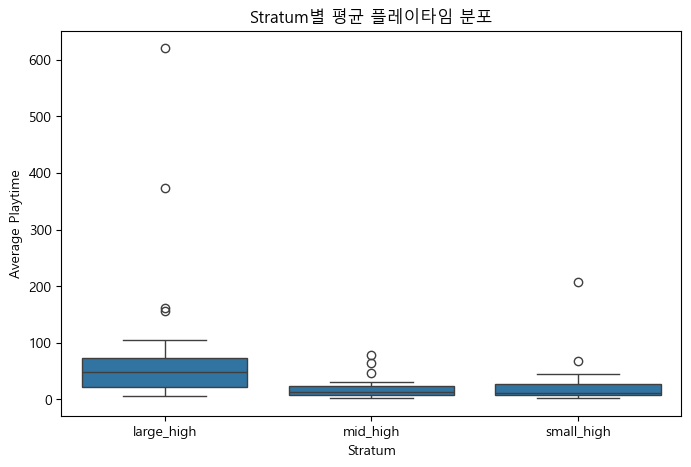

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.boxplot(data=df_clean, x="stratum", y="avg_playtime")
plt.title("Stratum별 평균 플레이타임 분포")
plt.xlabel("Stratum")
plt.ylabel("Average Playtime")
plt.show()

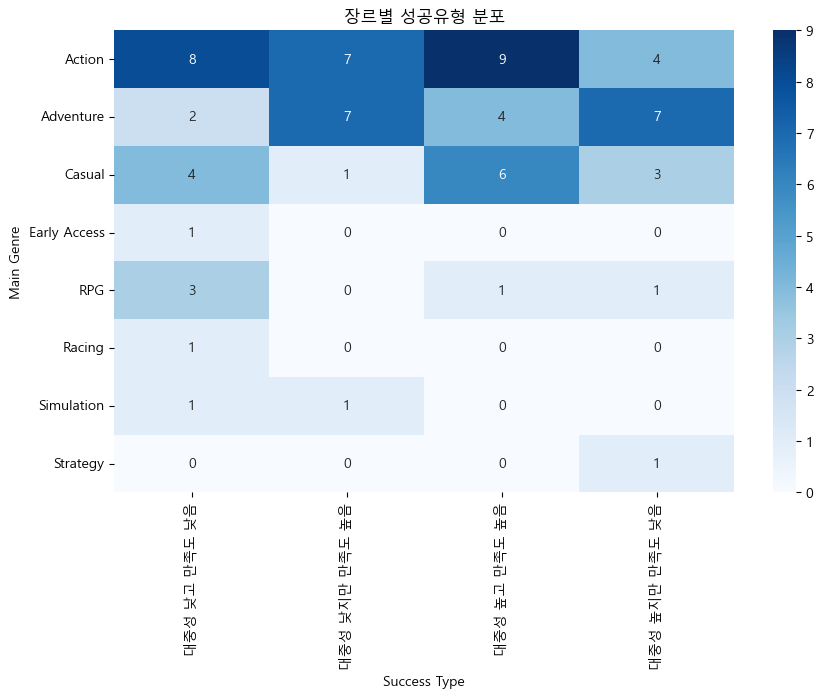

In [36]:
plt.figure(figsize=(10, 6))
sns.heatmap(genre_success, annot=True, fmt="d", cmap="Blues")
plt.title("장르별 성공유형 분포")
plt.xlabel("Success Type")
plt.ylabel("Main Genre")
plt.show()

장르별 플레이타임 요약

In [37]:
genre_playtime_summary = (
    df_clean.groupby("main_genre")
    .agg(
        game_count=("appid", "count"),
        avg_playtime_mean=("avg_playtime", "mean"),
        avg_playtime_median=("avg_playtime", "median"),
        positive_ratio_mean=("positive_ratio", "mean"),
        total_reviews_median=("total_reviews", "median")
    )
    .sort_values("avg_playtime_median", ascending=False)
    .reset_index()
)

genre_playtime_summary

,main_genre,game_count,avg_playtime_mean,avg_playtime_median,positive_ratio_mean,total_reviews_median
0,Strategy,1,620.149000,620.149000,0.670000,65046.0
1,Simulation,2,43.137889,43.137889,0.752222,619.0
2,Casual,14,71.831549,38.582000,0.781978,3292.0
3,RPG,5,35.442825,25.478125,0.764875,1084.0
4,Action,28,34.649465,16.527000,0.792894,994.0
5,Adventure,20,23.331218,12.935500,0.794897,1450.5
6,Early Access,1,8.454000,8.454000,0.770000,446.0
7,Racing,1,2.600000,2.600000,0.500000,538.0


In [38]:
genre_counts = df_clean["main_genre"].value_counts()

valid_genres = genre_counts[genre_counts >= 3].index

df_genre_valid = df_clean[df_clean["main_genre"].isin(valid_genres)].copy()

print(df_genre_valid["main_genre"].value_counts())

main_genre
Action       28
Adventure    20
Casual       14
RPG           5
Name: count, dtype: int64
